# Week 7 — Robot Sensor Anomaly Detection Benchmark

## Objective

This notebook evaluates anomaly detection methods on synthetic robot sensor data.

Five controlled fault types are injected into normal robot operation:

1. Motor stall
2. Proximity sensor drift
3. Battery degradation
4. IMU axis failure
5. RSSI disruption

Four anomaly detection approaches are benchmarked:

1. Frequency-band energy threshold
2. Isolation Forest
3. One-Class SVM
4. Supervised binary classifier

Performance is evaluated across 10 random seeds using precision, recall, F1 score, and AUROC. The two best-performing methods are further compared using a paired Wilcoxon signed-rank test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from scipy.stats import wilcoxon

RANDOM_SEEDS = list(range(10))

np.random.seed(42)

## 1. Load Week 2 Synthetic Robot Sensor Data

The synthetic robot sensor datasets generated in Week 2 are loaded below.
Both the 5-minute aggregated dataset and the high-frequency sensor dataset
are inspected before constructing the anomaly injection pipeline.

In [6]:
# Data paths

data_5min_path = "../data/robot_sensor_5min.csv"
data_highfreq_path = "../data/robot_sensor_highfreq.csv"

# Load datasets
df_5min = pd.read_csv(data_5min_path)
df_highfreq = pd.read_csv(data_highfreq_path)

print("5-minute dataset shape:", df_5min.shape)
print("High-frequency dataset shape:", df_highfreq.shape)

5-minute dataset shape: (120960, 12)
High-frequency dataset shape: (48000, 8)


In [7]:
print("=== 5-minute dataset ===")
display(df_5min.head())

print("\nColumns:")
print(df_5min.columns.tolist())

=== 5-minute dataset ===


,timestamp,robot_id,mode,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success,imu_magnitude
0,2026-08-10 00:00:00,R01,PATROL,0.181560,-0.022685,9.765057,1.806318,2.234491,-55.888431,93.100778,0,9.766771
1,2026-08-10 00:05:00,R01,PATROL,0.003813,-0.122254,9.707094,2.288695,4.781291,-61.387078,93.089032,1,9.707865
2,2026-08-10 00:10:00,R01,PATROL,0.114086,0.233848,9.832063,2.383943,5.134641,-56.865756,93.065962,1,9.835505
3,2026-08-10 00:15:00,R01,PATROL,0.412985,0.196385,9.728399,2.340912,2.719345,-61.019880,93.026576,1,9.739142
4,2026-08-10 00:20:00,R01,PATROL,0.264022,0.340855,10.063573,2.323048,2.675605,-55.376955,93.016117,1,10.072805



Columns:
['timestamp', 'robot_id', 'mode', 'accel_x', 'accel_y', 'accel_z', 'motor_current', 'proximity', 'rssi', 'battery_soc', 'task_success', 'imu_magnitude']


In [8]:
print("=== High-frequency dataset ===")
display(df_highfreq.head())

print("\nColumns:")
print(df_highfreq.columns.tolist())

=== High-frequency dataset ===


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0



Columns:
['time', 'mode', 'motor_current', 'accel_x', 'accel_y', 'accel_z', 'imu_magnitude', 'window_id']


In [9]:
print("=== 5-minute dataset info ===")
df_5min.info()

print("\n=== Missing values ===")
print(df_5min.isna().sum())

=== 5-minute dataset info ===
<class 'pandas.DataFrame'>
RangeIndex: 120960 entries, 0 to 120959
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      120960 non-null  str    
 1   robot_id       120960 non-null  str    
 2   mode           120960 non-null  str    
 3   accel_x        120960 non-null  float64
 4   accel_y        120960 non-null  float64
 5   accel_z        120960 non-null  float64
 6   motor_current  120960 non-null  float64
 7   proximity      120960 non-null  float64
 8   rssi           120960 non-null  float64
 9   battery_soc    120960 non-null  float64
 10  task_success   120960 non-null  int64  
 11  imu_magnitude  120960 non-null  float64
dtypes: float64(8), int64(1), str(3)
memory usage: 11.1 MB

=== Missing values ===
timestamp        0
robot_id         0
mode             0
accel_x          0
accel_y          0
accel_z          0
motor_current    0
proximity        0
rssi 

In [10]:
print("=== High-frequency dataset info ===")
df_highfreq.info()

print("\n=== Missing values ===")
print(df_highfreq.isna().sum())

=== High-frequency dataset info ===
<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           48000 non-null  float64
 1   mode           48000 non-null  str    
 2   motor_current  48000 non-null  float64
 3   accel_x        48000 non-null  float64
 4   accel_y        48000 non-null  float64
 5   accel_z        48000 non-null  float64
 6   imu_magnitude  48000 non-null  float64
 7   window_id      48000 non-null  int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 2.9 MB

=== Missing values ===
time             0
mode             0
motor_current    0
accel_x          0
accel_y          0
accel_z          0
imu_magnitude    0
window_id        0
dtype: int64


## 2. Extend the Synthetic Dataset for Fault Injection

The Week 2 synthetic telemetry did not include a velocity channel. Because the
Week 7 motor-stall definition requires a simultaneous motor-current spike and
velocity drop, a synthetic velocity signal is added while preserving the
original Week 2 datasets.

The velocity profile is generated according to the robot operating mode and
is used only for the Week 7 anomaly-injection benchmark.

In [11]:
# Create a Week 7 working copy
df_w7 = df_5min.copy()

# Reproducible random generator
rng = np.random.default_rng(42)

# Initialize velocity column
df_w7["velocity"] = 0.0

# Mode-specific synthetic velocity profiles
velocity_params = {
    "PATROL":   (0.80, 0.12),
    "ALERT":    (1.10, 0.18),
    "CHARGING": (0.02, 0.01),
    "FAULT":    (0.35, 0.20),
}

for mode, (mean_velocity, std_velocity) in velocity_params.items():
    mask = df_w7["mode"] == mode
    n = mask.sum()

    df_w7.loc[mask, "velocity"] = rng.normal(
        loc=mean_velocity,
        scale=std_velocity,
        size=n
    )

# Velocity cannot be negative
df_w7["velocity"] = df_w7["velocity"].clip(lower=0)

df_w7[["mode", "motor_current", "velocity"]].head(10)

,mode,motor_current,velocity
0,PATROL,1.806318,0.836566
1,PATROL,2.288695,0.675202
2,PATROL,2.383943,0.890054
3,PATROL,2.340912,0.912868
4,PATROL,2.323048,0.565876
5,PATROL,2.578081,0.643738
6,PATROL,2.305173,0.815341
7,PATROL,2.066452,0.762051
8,PATROL,1.659372,0.797984
9,PATROL,1.973321,0.697635


In [12]:
velocity_summary = (
    df_w7.groupby("mode")
    .agg(
        mean_velocity=("velocity", "mean"),
        std_velocity=("velocity", "std"),
        mean_motor_current=("motor_current", "mean"),
        sample_count=("velocity", "size")
    )
    .round(3)
)

display(velocity_summary)

,mean_velocity,std_velocity,mean_motor_current,sample_count
mode,,,,
ALERT,1.096,0.182,3.306,5244
CHARGING,0.020,0.010,0.200,17102
FAULT,0.357,0.193,4.502,2156
PATROL,0.800,0.120,2.001,96458


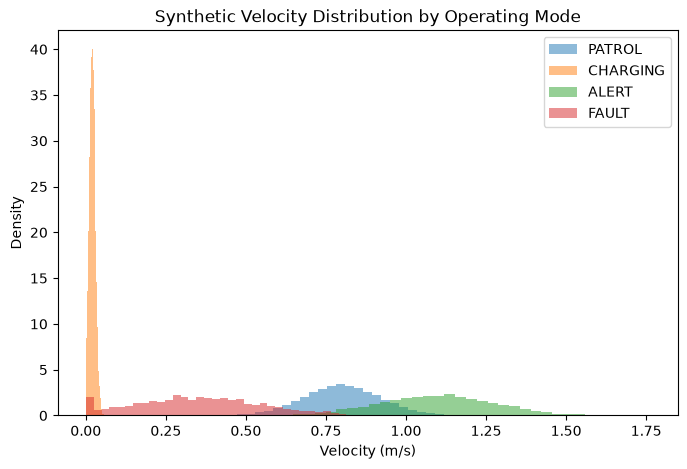

In [13]:
plt.figure(figsize=(8, 5))

for mode in df_w7["mode"].unique():
    subset = df_w7.loc[df_w7["mode"] == mode, "velocity"]

    plt.hist(
        subset,
        bins=40,
        alpha=0.5,
        label=mode,
        density=True
    )

plt.xlabel("Velocity (m/s)")
plt.ylabel("Density")
plt.title("Synthetic Velocity Distribution by Operating Mode")
plt.legend()
plt.show()

## 3. Define the Normal Operational Baseline

Controlled Week 7 anomalies should be evaluated against normal robot
operation. Therefore, the original Week 2 `FAULT` mode is excluded from
the normal baseline before injecting the five controlled fault types.

In [14]:
normal_df = (
    df_w7[df_w7["mode"] != "FAULT"]
    .copy()
    .reset_index(drop=True)
)

print("Original Week 7 working dataset:", df_w7.shape)
print("Normal baseline dataset:", normal_df.shape)

print("\nNormal baseline modes:")
print(normal_df["mode"].value_counts())

Original Week 7 working dataset: (120960, 13)
Normal baseline dataset: (118804, 13)

Normal baseline modes:
mode
PATROL      96458
CHARGING    17102
ALERT        5244
Name: count, dtype: int64


## 4. Controlled Fault Definition

### 4.1 Motor Stall

A motor stall is simulated as a sudden increase in motor current accompanied
by a sharp decrease in robot velocity. Motor stalls are injected only during
active operating modes (`PATROL` and `ALERT`), since the robot is already
nearly stationary during `CHARGING`.

The injected samples are labeled as anomalies to provide ground-truth labels
for evaluating the anomaly detection methods.

In [15]:
def inject_motor_stall(
    df,
    fault_fraction=0.05,
    seed=42
):
    """
    Inject synthetic motor-stall anomalies.

    A motor stall is represented by:
    - a sudden increase in motor current
    - a sharp decrease in velocity

    Faults are injected only during active modes
    (PATROL and ALERT).
    """

    data = df.copy()
    rng = np.random.default_rng(seed)

    # Ground-truth labels
    data["is_anomaly"] = 0
    data["fault_type"] = "normal"

    # Only inject stalls while the robot is moving
    eligible_mask = data["mode"].isin(["PATROL", "ALERT"])
    eligible_idx = data.index[eligible_mask].to_numpy()

    # Select anomaly samples
    n_faults = int(len(eligible_idx) * fault_fraction)

    fault_idx = rng.choice(
        eligible_idx,
        size=n_faults,
        replace=False
    )

    # Current spike: approximately 2.5–4× normal current
    current_multiplier = rng.uniform(
        2.5,
        4.0,
        size=n_faults
    )

    data.loc[fault_idx, "motor_current"] *= current_multiplier

    # Velocity drops to approximately 0–10% of normal
    velocity_multiplier = rng.uniform(
        0.0,
        0.1,
        size=n_faults
    )

    data.loc[fault_idx, "velocity"] *= velocity_multiplier

    # Ground-truth anomaly labels
    data.loc[fault_idx, "is_anomaly"] = 1
    data.loc[fault_idx, "fault_type"] = "motor_stall"

    return data

In [16]:
motor_stall_df = inject_motor_stall(
    normal_df,
    fault_fraction=0.05,
    seed=42
)

print(motor_stall_df["fault_type"].value_counts())

fault_type
normal         113719
motor_stall      5085
Name: count, dtype: int64


In [17]:
motor_stall_summary = (
    motor_stall_df
    .groupby("fault_type")[
        ["motor_current", "velocity"]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(motor_stall_summary)

motor_current                       velocity                  
                     mean    std    min     max     mean    std  min   max
fault_type                                                                
motor_stall         6.678  1.711  3.168  17.075    0.041  0.025  0.0  0.13
normal              1.788  0.786 -0.001   5.258    0.695  0.312  0.0  1.76

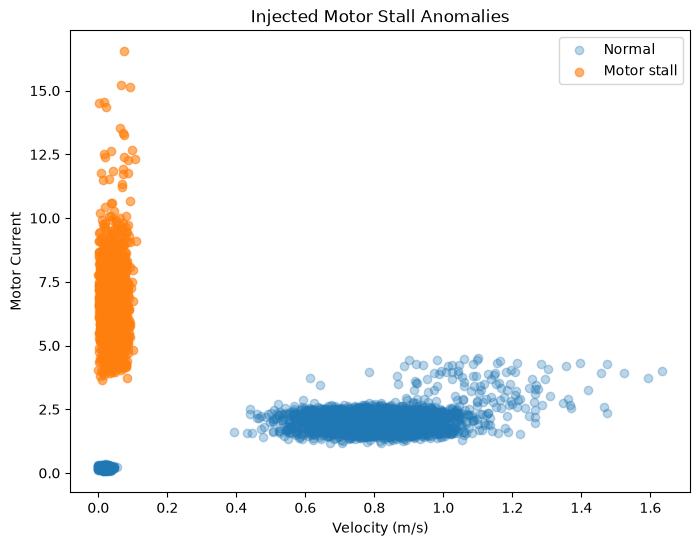

In [18]:
plt.figure(figsize=(8, 6))

normal_sample = motor_stall_df[
    motor_stall_df["is_anomaly"] == 0
].sample(
    n=3000,
    random_state=42
)

fault_sample = motor_stall_df[
    motor_stall_df["is_anomaly"] == 1
].sample(
    n=min(
        1000,
        (motor_stall_df["is_anomaly"] == 1).sum()
    ),
    random_state=42
)

plt.scatter(
    normal_sample["velocity"],
    normal_sample["motor_current"],
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    fault_sample["velocity"],
    fault_sample["motor_current"],
    alpha=0.6,
    label="Motor stall"
)

plt.xlabel("Velocity (m/s)")
plt.ylabel("Motor Current")
plt.title("Injected Motor Stall Anomalies")
plt.legend()
plt.show()

### 4.2 Proximity Sensor Drift

Proximity sensor drift is simulated as a gradual deviation from the normal
sensor reading over a continuous sequence of observations. Unlike an abrupt
sensor failure, the magnitude of the error increases progressively over time,
representing calibration drift or sensor degradation.

The affected observations are labeled as `proximity_drift` anomalies.

In [19]:
## injection function
def inject_proximity_drift(
    df,
    fault_fraction=0.05,
    seed=42
):
    """
    Inject gradual proximity-sensor drift.

    A continuous segment is selected and an increasing
    offset is added to the proximity measurements.
    """

    data = df.copy()
    rng = np.random.default_rng(seed)

    # Ground-truth labels
    data["is_anomaly"] = 0
    data["fault_type"] = "normal"

    n_faults = int(len(data) * fault_fraction)

    # Randomly choose one robot so that the drift is temporally meaningful
    robot_id = rng.choice(data["robot_id"].unique())

    robot_idx = data.index[
        data["robot_id"] == robot_id
    ].to_numpy()

    # Make sure the requested segment fits
    segment_length = min(n_faults, len(robot_idx))

    start_max = len(robot_idx) - segment_length
    start = rng.integers(0, start_max + 1)

    fault_idx = robot_idx[start:start + segment_length]

    # Estimate natural variability of the proximity sensor
    proximity_std = data["proximity"].std()

    # Gradually increase drift from 0.5 SD to 4 SD
    drift = np.linspace(
        0.5 * proximity_std,
        4.0 * proximity_std,
        segment_length
    )

    data.loc[fault_idx, "proximity"] += drift

    # Ground-truth labels
    data.loc[fault_idx, "is_anomaly"] = 1
    data.loc[fault_idx, "fault_type"] = "proximity_drift"

    return data

In [20]:
## run injection
proximity_drift_df = inject_proximity_drift(
    normal_df,
    fault_fraction=0.05,
    seed=42
)

print(proximity_drift_df["fault_type"].value_counts())

fault_type
normal             114814
proximity_drift      3990
Name: count, dtype: int64


In [21]:
proximity_summary = (
    proximity_drift_df
    .groupby("fault_type")["proximity"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(proximity_summary)

,mean,std,min,max
fault_type,,,,
normal,2.560,1.306,0.100,7.293
proximity_drift,5.421,1.900,0.893,11.351


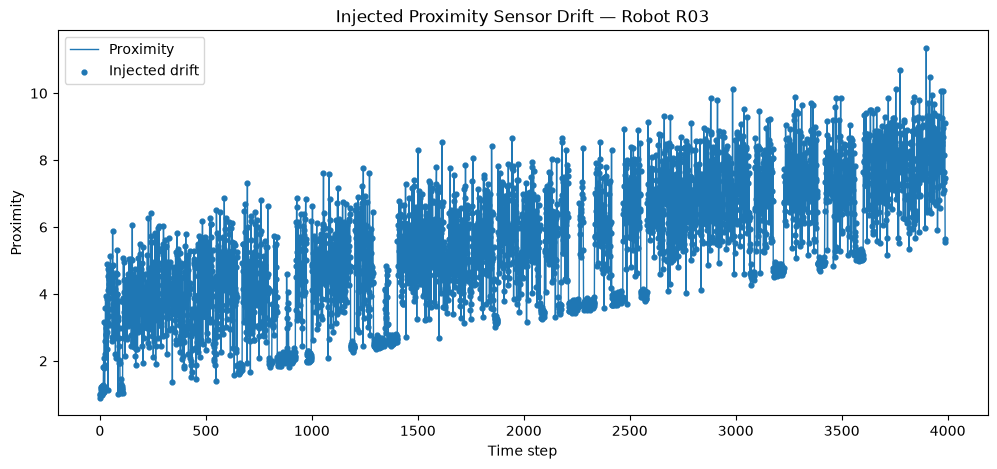

In [22]:
fault_rows = proximity_drift_df[
    proximity_drift_df["fault_type"] == "proximity_drift"
].copy()

fault_robot = fault_rows["robot_id"].iloc[0]

robot_data = proximity_drift_df[
    proximity_drift_df["robot_id"] == fault_robot
].copy()

robot_data = robot_data.sort_values("timestamp").reset_index(drop=True)

plt.figure(figsize=(12, 5))

plt.plot(
    robot_data["proximity"].values,
    linewidth=1,
    label="Proximity"
)

fault_mask = robot_data["fault_type"] == "proximity_drift"

plt.scatter(
    robot_data.index[fault_mask],
    robot_data.loc[fault_mask, "proximity"],
    s=12,
    label="Injected drift"
)

plt.xlabel("Time step")
plt.ylabel("Proximity")
plt.title(f"Injected Proximity Sensor Drift — Robot {fault_robot}")
plt.legend()
plt.show()

### 4.3 Battery Degradation Acceleration

Battery degradation is simulated as an abnormally accelerated decline in
battery state of charge (SOC) over a continuous operating period.

Unlike proximity sensor drift, which represents increasing measurement bias,
this fault represents a physical degradation process: the battery loses
charge progressively faster than expected during operation.

The affected observations are labeled as `battery_degradation` anomalies.

In [23]:
def inject_battery_degradation(
    df,
    fault_fraction=0.05,
    seed=42
):
    """
    Inject accelerated battery degradation.

    Battery SOC progressively decreases over a continuous
    sequence of observations.
    """

    data = df.copy()
    rng = np.random.default_rng(seed)

    # Ground-truth labels
    data["is_anomaly"] = 0
    data["fault_type"] = "normal"

    n_faults = int(len(data) * fault_fraction)

    # Select one robot for a continuous degradation episode
    robot_id = rng.choice(data["robot_id"].unique())

    robot_idx = data.index[
        data["robot_id"] == robot_id
    ].to_numpy()

    segment_length = min(n_faults, len(robot_idx))

    start_max = len(robot_idx) - segment_length
    start = rng.integers(0, start_max + 1)

    fault_idx = robot_idx[start:start + segment_length]

    # Progressive additional SOC loss
    degradation = np.linspace(
        0,
        35,
        segment_length
    )

    data.loc[fault_idx, "battery_soc"] -= degradation

    # SOC must remain physically valid
    data["battery_soc"] = data["battery_soc"].clip(
        lower=0,
        upper=100
    )

    # Ground-truth labels
    data.loc[fault_idx, "is_anomaly"] = 1
    data.loc[fault_idx, "fault_type"] = "battery_degradation"

    return data

In [24]:
battery_degradation_df = inject_battery_degradation(
    normal_df,
    fault_fraction=0.05,
    seed=42
)

print(
    battery_degradation_df["fault_type"].value_counts()
)

fault_type
normal                 114814
battery_degradation      3990
Name: count, dtype: int64


In [25]:
battery_summary = (
    battery_degradation_df
    .groupby("fault_type")["battery_soc"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(battery_summary)

,mean,std,min,max
fault_type,,,,
battery_degradation,63.352,8.107,42.063,81.611
normal,69.910,16.764,23.400,100.000


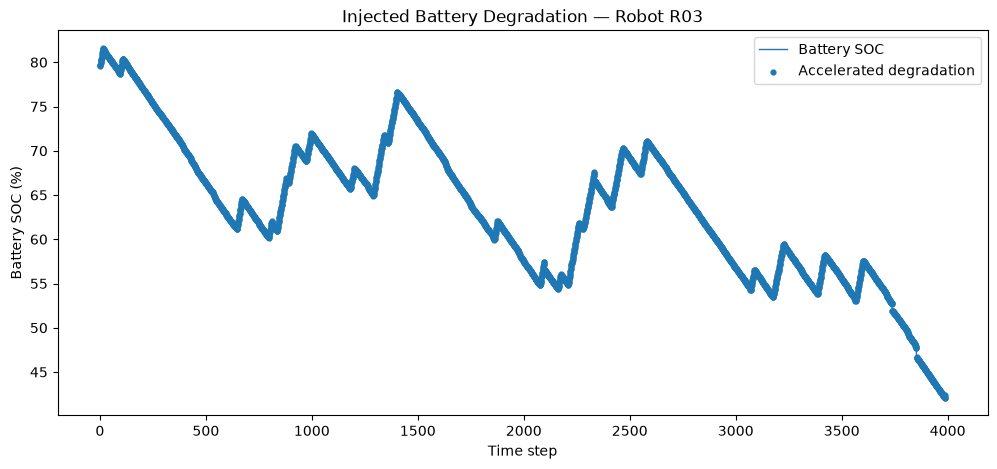

In [26]:
fault_rows = battery_degradation_df[
    battery_degradation_df["fault_type"]
    == "battery_degradation"
]

fault_robot = fault_rows["robot_id"].iloc[0]

robot_data = battery_degradation_df[
    battery_degradation_df["robot_id"] == fault_robot
].copy()

robot_data = (
    robot_data
    .sort_values("timestamp")
    .reset_index(drop=True)
)

fault_mask = (
    robot_data["fault_type"]
    == "battery_degradation"
)

plt.figure(figsize=(12, 5))

plt.plot(
    robot_data["battery_soc"],
    linewidth=1,
    label="Battery SOC"
)

plt.scatter(
    robot_data.index[fault_mask],
    robot_data.loc[fault_mask, "battery_soc"],
    s=12,
    label="Accelerated degradation"
)

plt.xlabel("Time step")
plt.ylabel("Battery SOC (%)")
plt.title(
    f"Injected Battery Degradation — Robot {fault_robot}"
)
plt.legend()
plt.show()

### 4.4 IMU Axis Failure

An IMU axis failure is simulated by forcing one accelerometer channel to zero
during affected observations. This represents a sensor channel that stops
reporting valid measurements while the remaining IMU axes continue operating.

For each injection run, one of the three accelerometer axes (`accel_x`,
`accel_y`, or `accel_z`) is randomly selected as the failed channel.

In [27]:
def inject_imu_failure(
    df,
    fault_fraction=0.05,
    seed=42
):
    """
    Inject an IMU axis failure by zeroing one accelerometer
    channel for a random subset of observations.
    """

    data = df.copy()
    rng = np.random.default_rng(seed)

    # Ground-truth labels
    data["is_anomaly"] = 0
    data["fault_type"] = "normal"

    n_faults = int(len(data) * fault_fraction)

    # Randomly select one IMU axis to fail
    imu_axes = ["accel_x", "accel_y", "accel_z"]
    failed_axis = rng.choice(imu_axes)

    # Randomly select affected samples
    fault_idx = rng.choice(
        data.index.to_numpy(),
        size=n_faults,
        replace=False
    )

    # Zero the failed channel
    data.loc[fault_idx, failed_axis] = 0.0

    # Recalculate IMU magnitude
    data["imu_magnitude"] = np.sqrt(
        data["accel_x"]**2
        + data["accel_y"]**2
        + data["accel_z"]**2
    )

    # Ground-truth labels
    data.loc[fault_idx, "is_anomaly"] = 1
    data.loc[fault_idx, "fault_type"] = "imu_failure"

    return data, failed_axis

In [28]:
imu_failure_df, failed_axis = inject_imu_failure(
    normal_df,
    fault_fraction=0.05,
    seed=42
)

print("Failed IMU axis:", failed_axis)

print("\nFault counts:")
print(imu_failure_df["fault_type"].value_counts())

Failed IMU axis: accel_x

Fault counts:
fault_type
normal         112864
imu_failure      5940
Name: count, dtype: int64


In [29]:
imu_summary = (
    imu_failure_df
    .groupby("fault_type")[
        ["accel_x", "accel_y", "accel_z", "imu_magnitude"]
    ]
    .mean()
    .round(3)
)

display(imu_summary)

,accel_x,accel_y,accel_z,imu_magnitude
fault_type,,,,
imu_failure,0.0,0.001,9.808,9.811
normal,-0.0,-0.001,9.810,9.819


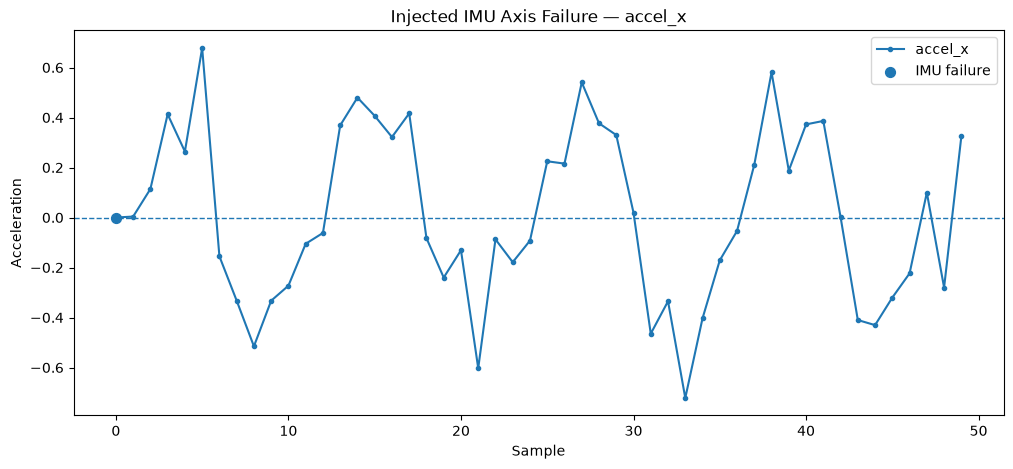

In [30]:
fault_indices = imu_failure_df.index[
    imu_failure_df["fault_type"] == "imu_failure"
]

sample_fault_idx = fault_indices[0]

start = max(0, sample_fault_idx - 50)
end = min(len(imu_failure_df), sample_fault_idx + 50)

plot_data = imu_failure_df.iloc[start:end]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data.index,
    plot_data[failed_axis],
    marker="o",
    markersize=3,
    label=failed_axis
)

fault_points = plot_data[
    plot_data["fault_type"] == "imu_failure"
]

plt.scatter(
    fault_points.index,
    fault_points[failed_axis],
    s=50,
    label="IMU failure"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Sample")
plt.ylabel("Acceleration")
plt.title(
    f"Injected IMU Axis Failure — {failed_axis}"
)
plt.legend()
plt.show()

### 4.5 RSSI Disruption

RSSI disruption is simulated as a sudden deterioration and increased
instability in wireless signal strength. During affected observations,
RSSI values become substantially more negative and exhibit additional
random fluctuations.

This represents intermittent communication interference or connectivity
degradation between the robot and its network.

In [31]:
def inject_rssi_disruption(
    df,
    fault_fraction=0.05,
    seed=42
):
    """
    Inject RSSI disruption by producing sudden signal-strength
    degradation and increased variability.
    """

    data = df.copy()
    rng = np.random.default_rng(seed)

    # Ground-truth labels
    data["is_anomaly"] = 0
    data["fault_type"] = "normal"

    n_faults = int(len(data) * fault_fraction)

    # Randomly select affected observations
    fault_idx = rng.choice(
        data.index.to_numpy(),
        size=n_faults,
        replace=False
    )

    # Signal drop: RSSI becomes more negative
    signal_drop = rng.uniform(
        15,
        30,
        size=n_faults
    )

    # Additional communication instability
    interference_noise = rng.normal(
        loc=0,
        scale=5,
        size=n_faults
    )

    data.loc[fault_idx, "rssi"] = (
        data.loc[fault_idx, "rssi"].to_numpy()
        - signal_drop
        + interference_noise
    )

    # Keep values within a plausible RSSI range
    data["rssi"] = data["rssi"].clip(
        lower=-120,
        upper=0
    )

    # Ground-truth labels
    data.loc[fault_idx, "is_anomaly"] = 1
    data.loc[fault_idx, "fault_type"] = "rssi_disruption"

    return data

In [32]:
rssi_disruption_df = inject_rssi_disruption(
    normal_df,
    fault_fraction=0.05,
    seed=42
)

print(rssi_disruption_df["fault_type"].value_counts())

fault_type
normal             112864
rssi_disruption      5940
Name: count, dtype: int64


In [33]:
rssi_summary = (
    rssi_disruption_df
    .groupby("fault_type")["rssi"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(rssi_summary)

,mean,std,min,max
fault_type,,,,
normal,-56.216,6.684,-84.193,-34.044
rssi_disruption,-78.746,9.394,-109.511,-44.391


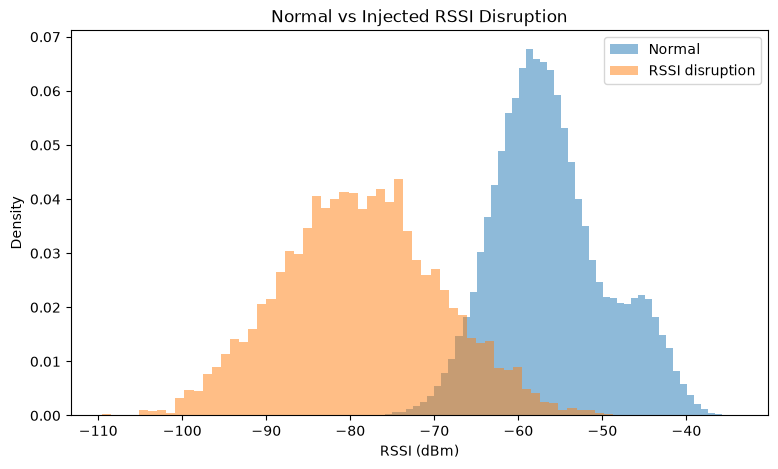

In [34]:
plt.figure(figsize=(9, 5))

normal_rssi = rssi_disruption_df.loc[
    rssi_disruption_df["fault_type"] == "normal",
    "rssi"
]

fault_rssi = rssi_disruption_df.loc[
    rssi_disruption_df["fault_type"] == "rssi_disruption",
    "rssi"
]

plt.hist(
    normal_rssi,
    bins=60,
    alpha=0.5,
    density=True,
    label="Normal"
)

plt.hist(
    fault_rssi,
    bins=60,
    alpha=0.5,
    density=True,
    label="RSSI disruption"
)

plt.xlabel("RSSI (dBm)")
plt.ylabel("Density")
plt.title("Normal vs Injected RSSI Disruption")
plt.legend()
plt.show()

## 5. Unified Fault Injection Pipeline

After validating each fault mechanism independently, the injection procedures
are standardized for the final benchmark.

Each fault type affects approximately 5% of eligible observations and is
introduced as continuous fault episodes rather than isolated random samples.
Random seeds control the locations of the injected episodes, enabling
reproducible evaluation across 10 independent runs.

In [35]:
def select_fault_episodes(
    df,
    n_faults,
    rng,
    eligible_mask=None,
    episode_length=100
):
    """
    Select approximately n_faults observations as continuous
    fault episodes within individual robots.
    """

    if eligible_mask is None:
        eligible_mask = pd.Series(True, index=df.index)

    selected = []
    available_robots = df.loc[
        eligible_mask, "robot_id"
    ].unique()

    attempts = 0
    max_attempts = 10000

    while len(selected) < n_faults and attempts < max_attempts:

        robot = rng.choice(available_robots)

        robot_idx = df.index[
            eligible_mask
            & (df["robot_id"] == robot)
        ].to_numpy()

        if len(robot_idx) == 0:
            attempts += 1
            continue

        current_length = min(
            episode_length,
            n_faults - len(selected),
            len(robot_idx)
        )

        start_max = len(robot_idx) - current_length
        start = rng.integers(0, start_max + 1)

        episode = robot_idx[
            start:start + current_length
        ]

        # Avoid overlapping previously selected samples
        new_indices = [
            idx for idx in episode
            if idx not in selected
        ]

        selected.extend(new_indices)
        attempts += 1

    return np.array(selected[:n_faults])

In [36]:
def inject_fault(
    df,
    fault_type,
    fault_fraction=0.05,
    seed=42,
    episode_length=100
):
    """
    Inject one controlled robot fault into normal operational data.

    Supported faults:
    - motor_stall
    - proximity_drift
    - battery_degradation
    - imu_failure
    - rssi_disruption
    """

    data = df.copy()
    rng = np.random.default_rng(seed)

    data["is_anomaly"] = 0
    data["fault_type"] = "normal"

    n_faults = int(len(data) * fault_fraction)

    # --------------------------------------------------
    # 1. Motor stall
    # --------------------------------------------------

    if fault_type == "motor_stall":

        eligible_mask = data["mode"].isin(
            ["PATROL", "ALERT"]
        )

        fault_idx = select_fault_episodes(
            data,
            n_faults,
            rng,
            eligible_mask=eligible_mask,
            episode_length=episode_length
        )

        data.loc[fault_idx, "motor_current"] *= rng.uniform(
            2.5,
            4.0,
            len(fault_idx)
        )

        data.loc[fault_idx, "velocity"] *= rng.uniform(
            0.0,
            0.1,
            len(fault_idx)
        )

    # --------------------------------------------------
    # 2. Proximity sensor drift
    # --------------------------------------------------

    elif fault_type == "proximity_drift":

        fault_idx = select_fault_episodes(
            data,
            n_faults,
            rng,
            episode_length=episode_length
        )

        proximity_std = data["proximity"].std()

        drift = np.linspace(
            0.5 * proximity_std,
            4.0 * proximity_std,
            len(fault_idx)
        )

        data.loc[fault_idx, "proximity"] += drift

    # --------------------------------------------------
    # 3. Battery degradation
    # --------------------------------------------------

    elif fault_type == "battery_degradation":

        fault_idx = select_fault_episodes(
            data,
            n_faults,
            rng,
            episode_length=episode_length
        )

        degradation = np.linspace(
            0,
            35,
            len(fault_idx)
        )

        data.loc[fault_idx, "battery_soc"] -= degradation

        data["battery_soc"] = data[
            "battery_soc"
        ].clip(0, 100)

    # --------------------------------------------------
    # 4. IMU axis failure
    # --------------------------------------------------

    elif fault_type == "imu_failure":

        fault_idx = select_fault_episodes(
            data,
            n_faults,
            rng,
            episode_length=episode_length
        )

        failed_axis = rng.choice(
            ["accel_x", "accel_y", "accel_z"]
        )

        data.loc[fault_idx, failed_axis] = 0.0

        data["imu_magnitude"] = np.sqrt(
            data["accel_x"]**2
            + data["accel_y"]**2
            + data["accel_z"]**2
        )

    # --------------------------------------------------
    # 5. RSSI disruption
    # --------------------------------------------------

    elif fault_type == "rssi_disruption":

        fault_idx = select_fault_episodes(
            data,
            n_faults,
            rng,
            episode_length=episode_length
        )

        signal_drop = rng.uniform(
            15,
            30,
            len(fault_idx)
        )

        interference = rng.normal(
            0,
            5,
            len(fault_idx)
        )

        data.loc[fault_idx, "rssi"] = (
            data.loc[fault_idx, "rssi"].to_numpy()
            - signal_drop
            + interference
        )

        data["rssi"] = data["rssi"].clip(
            -120,
            0
        )

    else:
        raise ValueError(
            f"Unknown fault type: {fault_type}"
        )

    # Ground-truth labels
    data.loc[fault_idx, "is_anomaly"] = 1
    data.loc[fault_idx, "fault_type"] = fault_type

    return data

In [37]:
FAULT_TYPES = [
    "motor_stall",
    "proximity_drift",
    "battery_degradation",
    "imu_failure",
    "rssi_disruption"
]

fault_datasets = {}

for fault in FAULT_TYPES:

    fault_df = inject_fault(
        normal_df,
        fault_type=fault,
        fault_fraction=0.05,
        seed=42,
        episode_length=100
    )

    fault_datasets[fault] = fault_df

    n_anomaly = fault_df["is_anomaly"].sum()
    percentage = (
        n_anomaly / len(fault_df) * 100
    )

    print(
        f"{fault:22s}: "
        f"{n_anomaly:5d} anomalies "
        f"({percentage:.2f}%)"
    )

motor_stall           :  5940 anomalies (5.00%)
proximity_drift       :  5940 anomalies (5.00%)
battery_degradation   :  5940 anomalies (5.00%)
imu_failure           :  5940 anomalies (5.00%)
rssi_disruption       :  5940 anomalies (5.00%)


## 6. Frequency-Band Feature Extraction

The neuroscience-inspired anomaly detection approach represents robot sensor
signals using frequency-band energy features. Similar to EEG analysis, raw
time-series signals are transformed into the frequency domain and summarized
by the energy contained within predefined frequency bands.

The Week 2 high-frequency dataset was generated at 20 Hz using 30-second
windows. Each original window therefore contains 600 samples.

Because the original `window_id` values are reused across operating modes,
a unique high-frequency window is identified by the combination of
`mode` and `window_id`.

For anomaly detection, each 30-second window is further divided into
non-overlapping 5-second analysis subwindows. This increases the number of
independent analysis units while preserving the original Week 2 dataset.

In [60]:
# Estimate sampling interval and frequency
time_values = np.sort(df_highfreq["time"].unique())

dt = np.median(np.diff(time_values))
FS = 1.0 / dt

print(f"Sampling interval: {dt:.3f} s")
print(f"Sampling frequency: {FS:.1f} Hz")
print(f"Nyquist frequency: {FS / 2:.1f} Hz")

Sampling interval: 0.050 s
Sampling frequency: 20.0 Hz
Nyquist frequency: 10.0 Hz


In [61]:

n_windows = (
    df_highfreq[["mode", "window_id"]]
    .drop_duplicates()
    .shape[0]
)

print("Number of high-frequency windows:", n_windows)

print(
    "\nSamples per window:"
)

display(
    df_highfreq
    .groupby(["mode", "window_id"])
    .size()
    .describe()
)

Number of high-frequency windows: 80

Samples per window:


count     80.0
mean     600.0
std        0.0
min      600.0
25%      600.0
50%      600.0
75%      600.0
max      600.0
dtype: float64

In [62]:
first_mode = "PATROL"
first_window_id = 0

first_window = df_highfreq[
    (df_highfreq["mode"] == first_mode) &
    (df_highfreq["window_id"] == first_window_id)
]

print("Mode:", first_mode)
print("Window ID:", first_window_id)
print("Samples:", len(first_window))

display(first_window.head())

Mode: PATROL
Window ID: 0
Samples: 600


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0


### 6.2 Analysis Subwindows

Each original 30-second high-frequency window contains 600 samples at 20 Hz.
For anomaly detection, the signal is divided into non-overlapping 5-second
subwindows.

Each analysis subwindow therefore contains:

5 seconds × 20 Hz = 100 samples.

Each original window produces six subwindows, resulting in 480 analysis
windows from the 80 original Week 2 windows.

In [64]:
SUBWINDOW_SECONDS = 5

SUBWINDOW_SAMPLES = round(
    FS * SUBWINDOW_SECONDS
)

print(
    "Subwindow duration:",
    SUBWINDOW_SECONDS,
    "seconds"
)

print(
    "Samples per subwindow:",
    SUBWINDOW_SAMPLES
)

print(
    "Expected number of analysis windows:",
    n_windows * (600 // SUBWINDOW_SAMPLES)
)

Subwindow duration: 5 seconds
Samples per subwindow: 100
Expected number of analysis windows: 480


In [66]:
subwindow_rows = []

for (mode, window_id), group in df_highfreq.groupby(
    ["mode", "window_id"]
):

    group = (
        group
        .sort_values("time")
        .reset_index(drop=True)
    )

    n_subwindows = (
        len(group) // SUBWINDOW_SAMPLES
    )

    for subwindow_id in range(n_subwindows):

        start = (
            subwindow_id
            * SUBWINDOW_SAMPLES
        )

        end = (
            start
            + SUBWINDOW_SAMPLES
        )

        subwindow = group.iloc[
            start:end
        ].copy()

        subwindow["original_window_id"] = window_id
        subwindow["subwindow_id"] = subwindow_id

        # Globally unique analysis-window identifier
        subwindow["analysis_window_id"] = (
            f"{mode}_{window_id}_{subwindow_id}"
        )

        subwindow_rows.append(
            subwindow
        )

df_subwindows = pd.concat(
    subwindow_rows,
    ignore_index=True
)

In [67]:
print(
    "Total raw samples:",
    len(df_subwindows)
)

print(
    "Number of analysis windows:",
    df_subwindows[
        "analysis_window_id"
    ].nunique()
)

print(
    "\nSamples per analysis window:"
)

display(
    df_subwindows
    .groupby("analysis_window_id")
    .size()
    .describe()
)

Total raw samples: 48000
Number of analysis windows: 480

Samples per analysis window:


count    480.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64

### 6.4 Robot Frequency Bands

The high-frequency signals have a sampling rate of 20 Hz and therefore a
Nyquist frequency of 10 Hz.

Three frequency ranges are used to summarize the robot sensor dynamics:

- Low frequency: 0.2–1 Hz
- Mid frequency: 1–3 Hz
- High frequency: 3–8 Hz

These bands are not intended to correspond directly to canonical EEG bands.
Instead, they transfer the neuroscience-inspired concept of frequency-band
energy to robot sensor signals.

In [68]:
FREQ_BANDS = {
    "low":  (0.2, 1.0),
    "mid":  (1.0, 3.0),
    "high": (3.0, 8.0)
}

FREQ_BANDS

{'low': (0.2, 1.0), 'mid': (1.0, 3.0), 'high': (3.0, 8.0)}

### 6.5 Define Band Energy


In [69]:
from scipy.signal import welch

def compute_band_energy(
    signal,
    fs=FS,
    bands=FREQ_BANDS
):
    """
    Compute frequency-band energy using
    Welch power spectral density.
    """

    signal = np.asarray(
        signal,
        dtype=float
    )

    # Remove DC offset
    signal = (
        signal
        - np.mean(signal)
    )

    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=len(signal)
    )

    features = {}

    for band_name, (low, high) in bands.items():

        mask = (
            (freqs >= low)
            & (freqs < high)
        )

        if mask.sum() > 1:

            energy = np.trapezoid(
                psd[mask],
                freqs[mask]
            )

        else:
            energy = 0.0

        features[
            f"{band_name}_energy"
        ] = energy

    return features

In [70]:
example_id = (
    df_subwindows[
        "analysis_window_id"
    ].iloc[0]
)

example_window = df_subwindows[
    df_subwindows["analysis_window_id"]
    == example_id
]

print(
    "Analysis window:",
    example_id
)

print(
    "Samples:",
    len(example_window)
)

example_energy = compute_band_energy(
    example_window[
        "motor_current"
    ].values
)

example_energy

Analysis window: ALERT_0_0
Samples: 100


{'low_energy': np.float64(0.018865177359593255),
 'mid_energy': np.float64(0.09109881895324422),
 'high_energy': np.float64(0.009878053076900904)}

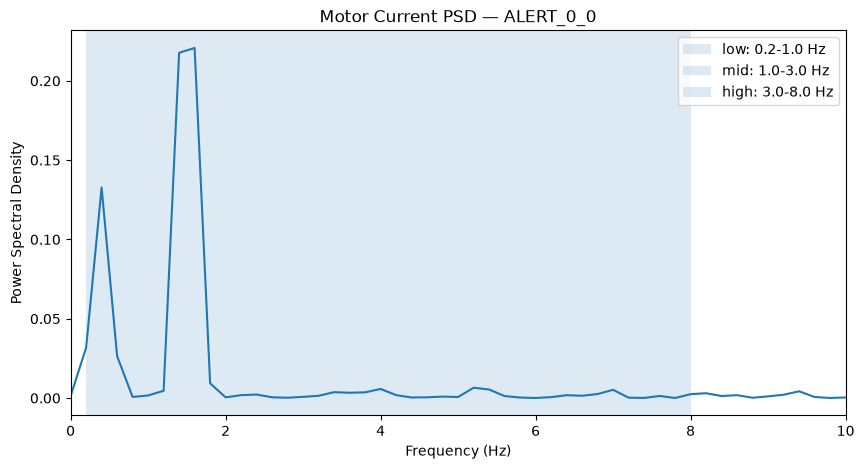

In [71]:
signal = (
    example_window[
        "motor_current"
    ].values
)

signal = signal - np.mean(signal)

freqs, psd = welch(
    signal,
    fs=FS,
    nperseg=len(signal)
)

plt.figure(figsize=(10, 5))

plt.plot(
    freqs,
    psd,
    linewidth=1.5
)

for band_name, (low, high) in FREQ_BANDS.items():

    plt.axvspan(
        low,
        high,
        alpha=0.15,
        label=(
            f"{band_name}: "
            f"{low}-{high} Hz"
        )
    )

plt.xlim(0, FS / 2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")

plt.title(
    f"Motor Current PSD — {example_id}"
)

plt.legend()
plt.show()

In [72]:
SPECTRAL_SIGNALS = [
    "motor_current",
    "accel_x",
    "accel_y",
    "accel_z",
    "imu_magnitude"
]

In [73]:
def extract_spectral_features(
    window_df,
    fs=FS,
    bands=FREQ_BANDS
):
    """
    Extract frequency-band energy features
    from one analysis window.
    """

    features = {}

    for signal_name in SPECTRAL_SIGNALS:

        band_features = compute_band_energy(
            window_df[signal_name].values,
            fs=fs,
            bands=bands
        )

        for band_name, value in band_features.items():

            features[
                f"{signal_name}_{band_name}"
            ] = value

    return features

In [74]:
spectral_rows = []

for analysis_window_id, window_df in (
    df_subwindows.groupby(
        "analysis_window_id"
    )
):

    features = extract_spectral_features(
        window_df
    )

    features[
        "analysis_window_id"
    ] = analysis_window_id

    features["mode"] = (
        window_df["mode"].iloc[0]
    )

    features[
        "original_window_id"
    ] = (
        window_df[
            "original_window_id"
        ].iloc[0]
    )

    features[
        "subwindow_id"
    ] = (
        window_df[
            "subwindow_id"
        ].iloc[0]
    )

    spectral_rows.append(
        features
    )

spectral_features = pd.DataFrame(
    spectral_rows
)

In [75]:
print(
    "Spectral feature matrix shape:",
    spectral_features.shape
)

display(
    spectral_features.head()
)

Spectral feature matrix shape: (480, 19)


,motor_current_low_energy,motor_current_mid_energy,motor_current_high_energy,accel_x_low_energy,accel_x_mid_energy,accel_x_high_energy,accel_y_low_energy,accel_y_mid_energy,accel_y_high_energy,accel_z_low_energy,accel_z_mid_energy,accel_z_high_energy,imu_magnitude_low_energy,imu_magnitude_mid_energy,imu_magnitude_high_energy,analysis_window_id,mode,original_window_id,subwindow_id
0,0.018865,0.091099,0.009878,0.033407,0.042178,0.007364,0.029684,0.039776,0.006940,0.000217,0.030190,0.005289,0.000202,0.029865,0.005341,ALERT_0_0,ALERT,0,0
1,0.017785,0.084027,0.012278,0.040258,0.049224,0.005706,0.025256,0.039120,0.004155,0.001363,0.031019,0.003445,0.001386,0.031095,0.003506,ALERT_0_1,ALERT,0,1
2,0.019290,0.107036,0.010903,0.040495,0.039118,0.008959,0.029420,0.032354,0.011810,0.000683,0.030486,0.007940,0.000672,0.030390,0.007765,ALERT_0_2,ALERT,0,2
3,0.042397,0.081164,0.013483,0.050526,0.057880,0.010231,0.027775,0.029393,0.006081,0.000625,0.033353,0.003881,0.000680,0.033018,0.003631,ALERT_0_3,ALERT,0,3
4,0.022027,0.103093,0.012981,0.047308,0.043966,0.006131,0.024652,0.040187,0.006827,0.001508,0.034849,0.007226,0.001425,0.034648,0.007115,ALERT_0_4,ALERT,0,4


In [76]:
energy_columns = [
    col
    for col in spectral_features.columns
    if col.endswith("_energy")
]

print(
    "Number of spectral features:",
    len(energy_columns)
)

print(
    "Missing spectral values:",
    spectral_features[
        energy_columns
    ].isna().sum().sum()
)

print(
    "Infinite spectral values:",
    np.isinf(
        spectral_features[
            energy_columns
        ].to_numpy()
    ).sum()
)

Number of spectral features: 15
Missing spectral values: 0
Infinite spectral values: 0


In [77]:
mode_energy_summary = (
    spectral_features
    .groupby("mode")[
        energy_columns
    ]
    .mean()
    .round(4)
)

display(
    mode_energy_summary
)

,motor_current_low_energy,motor_current_mid_energy,motor_current_high_energy,accel_x_low_energy,accel_x_mid_energy,accel_x_high_energy,accel_y_low_energy,accel_y_mid_energy,accel_y_high_energy,accel_z_low_energy,accel_z_mid_energy,accel_z_high_energy,imu_magnitude_low_energy,imu_magnitude_mid_energy,imu_magnitude_high_energy
mode,,,,,,,,,,,,,,,
ALERT,0.0242,0.1046,0.0111,0.0413,0.0478,0.0070,0.0318,0.0336,0.0068,0.0006,0.0327,0.0050,0.0006,0.0326,0.0050
CHARGING,0.0001,0.0002,0.0004,0.0000,0.0001,0.0002,0.0000,0.0001,0.0002,0.0000,0.0001,0.0002,0.0000,0.0001,0.0002
FAULT,0.0217,0.1440,0.4487,0.0186,0.0326,0.1542,0.0230,0.0108,0.2061,0.0025,0.0072,0.1978,0.0025,0.0073,0.1972
PATROL,0.0190,0.0021,0.0047,0.0157,0.0012,0.0032,0.0152,0.0011,0.0030,0.0058,0.0007,0.0017,0.0058,0.0007,0.0017


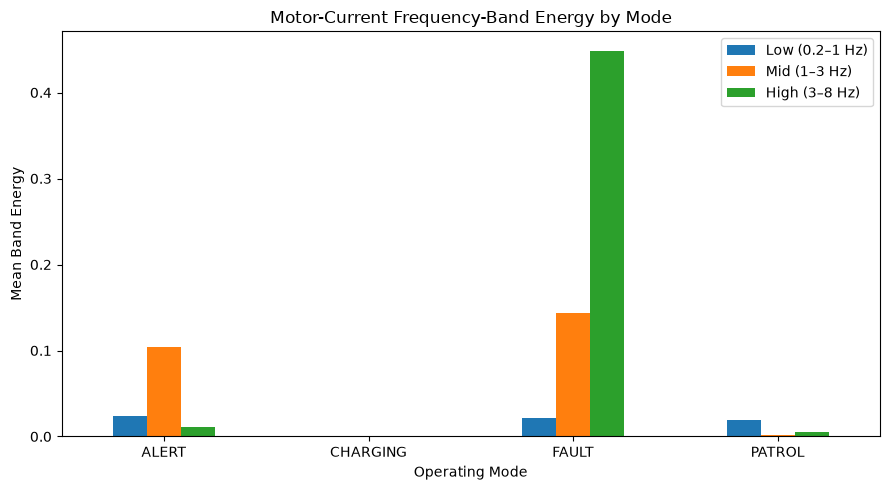

In [78]:
motor_energy_cols = [
    "motor_current_low_energy",
    "motor_current_mid_energy",
    "motor_current_high_energy"
]

motor_energy_plot = (
    spectral_features
    .groupby("mode")[
        motor_energy_cols
    ]
    .mean()
)

motor_energy_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Mean Band Energy")
plt.xlabel("Operating Mode")

plt.title(
    "Motor-Current Frequency-Band Energy by Mode"
)

plt.xticks(rotation=0)

plt.legend(
    [
        "Low (0.2–1 Hz)",
        "Mid (1–3 Hz)",
        "High (3–8 Hz)"
    ]
)

plt.tight_layout()
plt.show()